# Notebook 00 — Main

Concise end-to-end summary of the NMD rate model. This notebook **loads** the
trained models from `../data/*.pkl` (produced by notebooks 02–06) and calls
helper functions from `../src` to display the headline results.

**Pipeline:**
1. ECB AAA yield curve (real data, 2014–2024, 132 monthly observations)
2. Diebold-Li state-space → filtered Level/Slope/Curvature
3. ECM repricing with Markov regime switching → segment-specific pass-through
4. Volume model with regime-varying spread sensitivity → NII
5. IRRBB scenarios → deposit rates and NII at the 12-month horizon

**Prerequisite:** run notebooks 02_data → 03_diebold_li → 04_repricing → 05_pipeline → 06_volume once to populate `../data/`.
Re-running this notebook alone is fast (no MCMC).

In [1]:
import sys
sys.path.insert(0, "../src")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from simulate import SEGMENTS, MATURITIES, TRUE_GAMMA, TRUE_BETA_L_R1
from diebold_li import LAMBDA_MAT
from volume import TRUE_RHO, TRUE_BETA_V_R0, TRUE_BETA_V_R1

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
SEG_COLORS      = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
SCENARIO_COLORS = ["#333333", "#d62728", "#1f77b4", "#8c564b", "#bcbd22"]

with open("../data/ecb_data.pkl",        "rb") as f: ecb  = pickle.load(f)
with open("../data/dl_results.pkl",      "rb") as f: dl   = pickle.load(f)
with open("../data/ecm_results.pkl",     "rb") as f: ecm  = pickle.load(f)
with open("../data/pipeline_results.pkl","rb") as f: pipe = pickle.load(f)
with open("../data/volume_results.pkl", "rb") as f: vol  = pickle.load(f)

yields           = ecb["yields"]
deposits         = ecb["deposits"]
regime_true      = ecb["regime_seq"].values
factors_filtered = dl["factors_filtered"]
idata_ecm        = ecm["idata"]
xi_filtered      = ecm["xi_filtered"]
idata_vol        = vol["idata"]
volumes_df       = vol["volumes_hist"]
dates            = yields.index

print(f"Period: {dates[0].date()} → {dates[-1].date()}  ({len(dates)} months)")
print(f"Segments: {SEGMENTS}")

Period: 2014-01-01 → 2024-12-01  (132 months)
Segments: ['Retail Current', 'Retail Savings', 'SME Operational', 'Corporate']


## 1. ECB yield curve and Diebold-Li factors

Real data, with the regime split (low rate → hiking) shaded from January 2022.

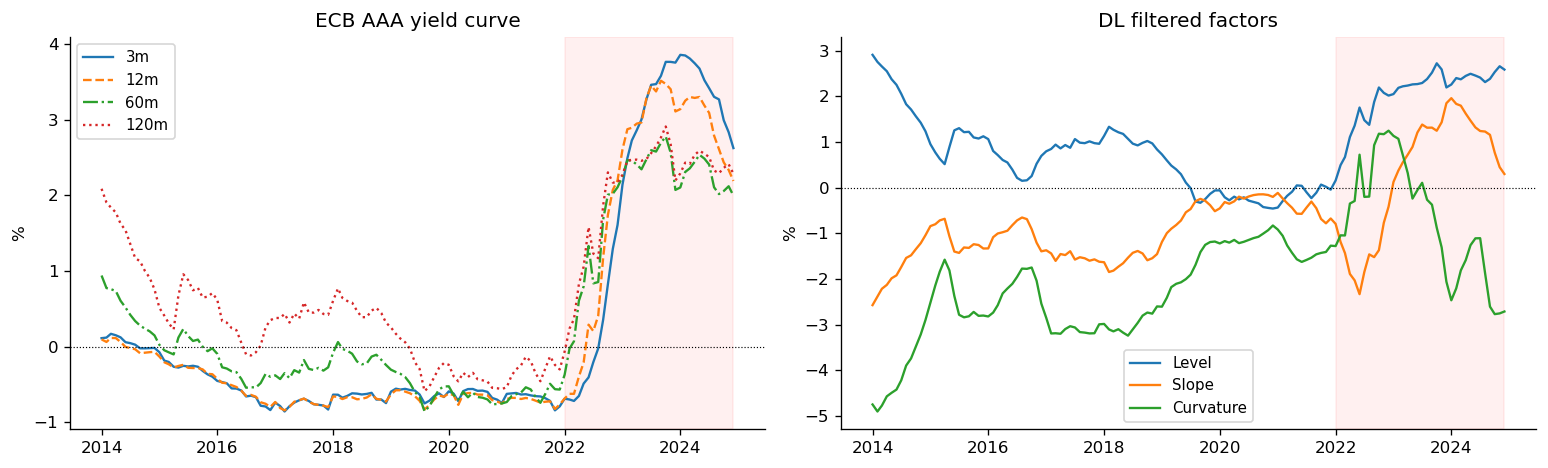

Yield curve fit RMSE: 0.0661%


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for col, ls in zip(["3m", "12m", "60m", "120m"], ["-", "--", "-.", ":"]):
    ax.plot(yields.index, yields[col], lw=1.4, ls=ls, label=col)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("ECB AAA yield curve")
ax.set_ylabel("%"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax = axes[1]
for col, color in zip(["Level", "Slope", "Curvature"], ["#1f77b4", "#ff7f0e", "#2ca02c"]):
    ax.plot(factors_filtered.index, factors_filtered[col], color=color, lw=1.4, label=col)
ax.axhline(0, color="black", lw=0.7, ls=":")
ax.axvspan(pd.Timestamp("2022-01-01"), dates[-1], alpha=0.06, color="red")
ax.set_title("DL filtered factors")
ax.set_ylabel("%"); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout(); plt.show()

y_fit = factors_filtered.values @ LAMBDA_MAT.T
rmse  = float(np.sqrt(np.mean((yields.values - y_fit) ** 2)))
print(f"Yield curve fit RMSE: {rmse:.4f}%")

## 2. Regime detection (Hamilton filter)

Filtered probability of the hiking regime, against the true regime sequence.

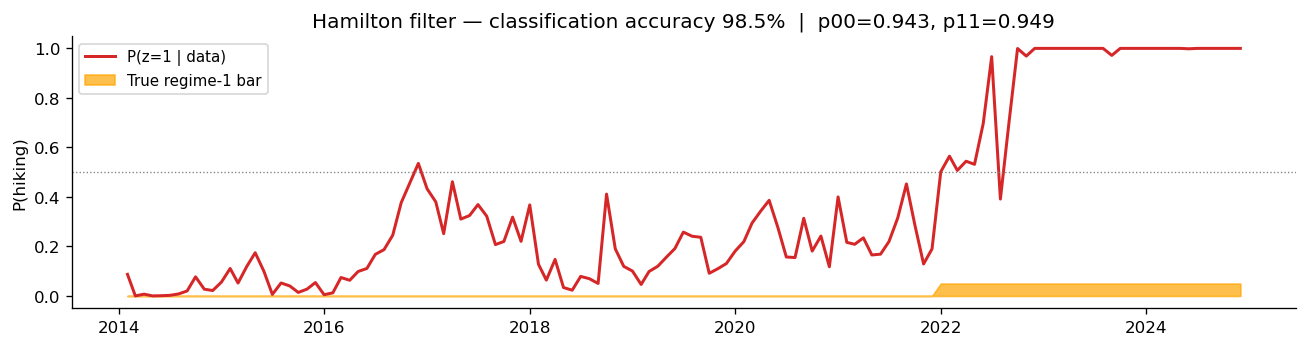

In [3]:
dates_filt = xi_filtered.index
p_hiking   = xi_filtered["P_regime_1"].values
true_r1    = (regime_true[1:] == 1).astype(int)
accuracy   = ((p_hiking > 0.5).astype(int) == true_r1).mean()

post = idata_ecm.posterior
p00 = float(post["p00"].mean(("chain", "draw")).values)
p11 = float(post["p11"].mean(("chain", "draw")).values)

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates_filt, p_hiking, color="#d62728", lw=1.8, label="P(z=1 | data)")
ax.fill_between(dates_filt, 0, true_r1 * 0.05, color="orange", alpha=0.7, label="True regime-1 bar")
ax.axhline(0.5, color="gray", lw=0.8, ls=":")
ax.set_ylim(-0.05, 1.05); ax.set_ylabel("P(hiking)")
ax.set_title(f"Hamilton filter — classification accuracy {accuracy:.1%}  |  p00={p00:.3f}, p11={p11:.3f}")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); plt.show()

## 3. Parameter recovery

In [4]:
gamma_mean  = post["gamma"].mean(("chain", "draw")).values
beta_L_mean = post["beta_L"].mean(("chain", "draw")).values   # (2, S)

post_v = idata_vol.posterior
rho_v   = post_v["rho"].mean(("chain", "draw")).values
beta0_v = post_v["beta0"].mean(("chain", "draw")).values
beta1_v = beta0_v + post_v["delta_beta"].mean(("chain", "draw")).values

rows = []
for s, seg in enumerate(SEGMENTS):
    rows.append({
        "Segment":     seg,
        "gamma (true)":  f"{TRUE_GAMMA[s]:+.3f}",
        "gamma (est)":   f"{gamma_mean[s]:+.3f}",
        "beta_L^1 (true)": f"{TRUE_BETA_L_R1[s]:.3f}",
        "beta_L^1 (est)":  f"{beta_L_mean[1, s]:.3f}",
        "rho (true)":    f"{TRUE_RHO[s]:.3f}",
        "rho (est)":     f"{rho_v[s]:.3f}",
        "beta_V^1 (true)": f"{TRUE_BETA_V_R1[s]:+.4f}",
        "beta_V^1 (est)":  f"{beta1_v[s]:+.4f}",
    })
summary = pd.DataFrame(rows).set_index("Segment")
print("ECM repricing γ and hiking-regime pass-through β_L^1, plus volume ρ and β_V^1:")
print(summary.to_string())

ECM repricing γ and hiking-regime pass-through β_L^1, plus volume ρ and β_V^1:
                gamma (true) gamma (est) beta_L^1 (true) beta_L^1 (est) rho (true) rho (est) beta_V^1 (true) beta_V^1 (est)
Segment                                                                                                                    
Retail Current        -0.200      -0.203           0.200          0.132      0.980     0.981         -0.0500        -0.0461
Retail Savings        -0.250      -0.204           0.350          0.288      0.950     0.951         -0.0800        -0.0693
SME Operational       -0.300      -0.310           0.500          0.428      0.920     0.928         -0.1200        -0.0848
Corporate             -0.400      -0.525           0.750          0.656      0.880     0.895         -0.2000        -0.1608


## 4. Scenario forecasts at the 12-month horizon

Five IRRBB scenarios applied to the last observed yield curve, propagated
through the ECM and volume models.

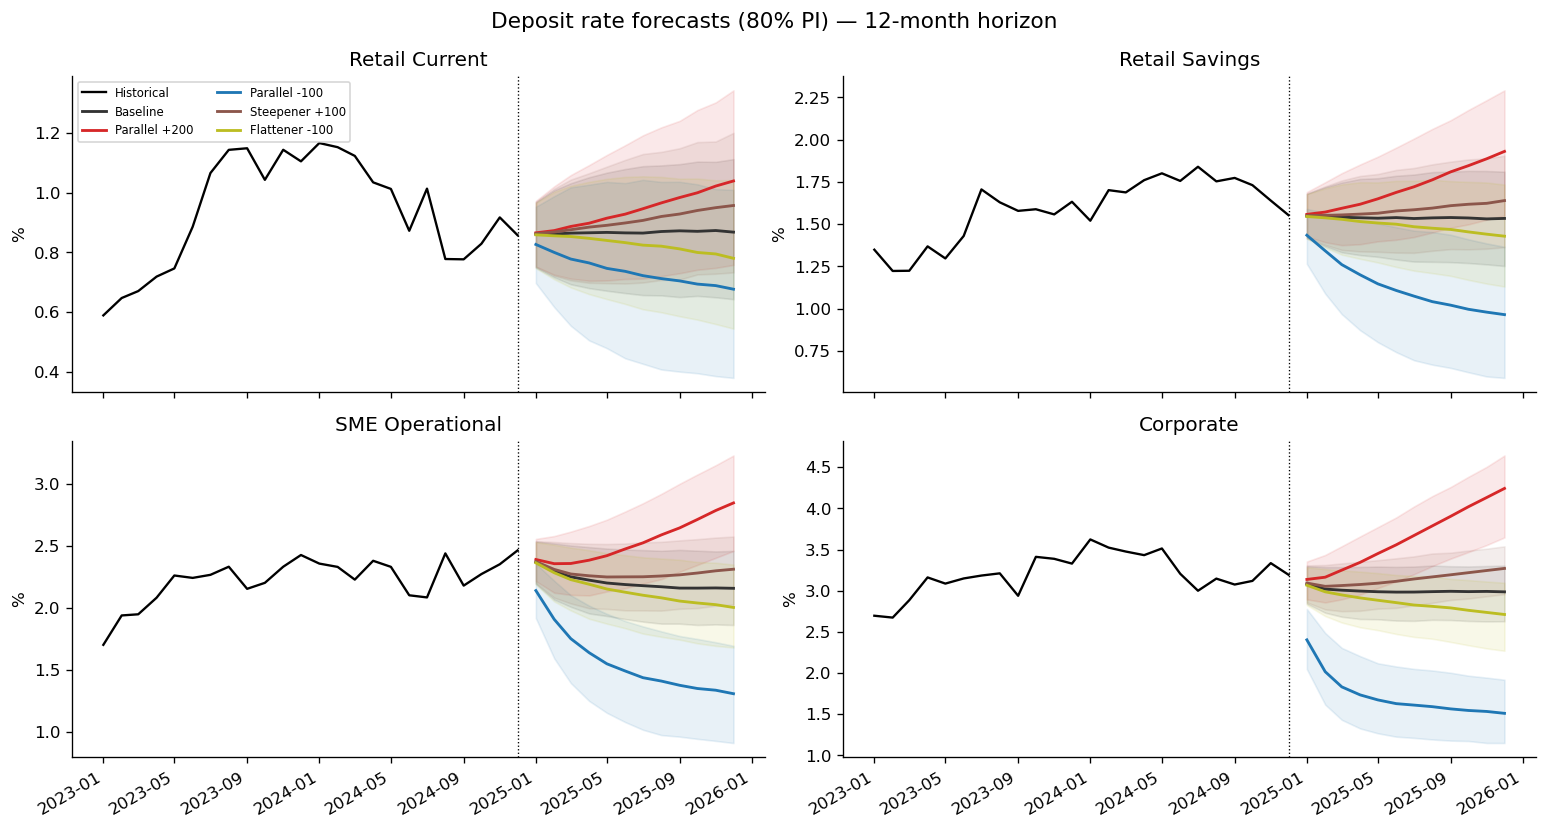

In [5]:
scenario_names    = pipe["scenario_names"]
scenario_deposits = pipe["scenario_deposits"]  # name → (N, H, S)
forecast_dates    = pipe["forecast_dates"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for s, (ax, seg, c) in enumerate(zip(axes.flat, SEGMENTS, SEG_COLORS)):
    ax.plot(deposits.index[-24:], deposits[seg].iloc[-24:], color="black", lw=1.4, label="Historical")
    for (name, ppc), sc in zip(scenario_deposits.items(), SCENARIO_COLORS):
        med = np.median(ppc[:, :, s], axis=0)
        lo  = np.percentile(ppc[:, :, s], 10, axis=0)
        hi  = np.percentile(ppc[:, :, s], 90, axis=0)
        ax.fill_between(forecast_dates, lo, hi, color=sc, alpha=0.10)
        ax.plot(forecast_dates, med, color=sc, lw=1.7, label=name)
    ax.axvline(deposits.index[-1], color="black", lw=0.8, ls=":")
    ax.set_title(seg); ax.set_ylabel("%")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    if s == 0:
        ax.legend(fontsize=7, ncol=2)
fig.suptitle("Deposit rate forecasts (80% PI) — 12-month horizon", fontsize=13)
fig.autofmt_xdate(rotation=30); fig.tight_layout(); plt.show()

In [6]:
rows = []
for name, ppc in scenario_deposits.items():
    medians = np.median(ppc[:, -1, :], axis=0)   # (S,) at H=12
    row = {"Scenario": name}
    for s, seg in enumerate(SEGMENTS):
        row[seg] = f"{medians[s]:.2f}%"
    rows.append(row)
tbl_rates = pd.DataFrame(rows).set_index("Scenario")

print("Posterior median deposit rate at H=12:")
print(tbl_rates.to_string())
print()

# Headline pass-through under +200bp parallel
ppc_base = scenario_deposits["Baseline"][:, -1, :]
ppc_up   = scenario_deposits["Parallel +200"][:, -1, :]
pt12     = np.median((ppc_up - ppc_base) / 2.0, axis=0)
print("12-month cumulative pass-through under Parallel +200bp:")
for s, seg in enumerate(SEGMENTS):
    print(f"  {seg:<22}: {pt12[s]*100:5.1f}%")

Posterior median deposit rate at H=12:
               Retail Current Retail Savings SME Operational Corporate
Scenario                                                              
Baseline                0.87%          1.53%           2.16%     2.99%
Parallel +200           1.04%          1.93%           2.85%     4.24%
Parallel -100           0.68%          0.96%           1.31%     1.51%
Steepener +100          0.96%          1.64%           2.31%     3.27%
Flattener -100          0.78%          1.43%           2.01%     2.71%

12-month cumulative pass-through under Parallel +200bp:
  Retail Current        :   8.5%
  Retail Savings        :  19.7%
  SME Operational       :  34.8%
  Corporate             :  62.5%
